In [2]:
import os
import numpy as np
import scanpy as sc
import torch
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors

import importlib
import SpatialGlue
importlib.reload(SpatialGlue)

from SpatialGlue import SpatialGlueMini, train_model

In [5]:
adata_rna = sc.read_h5ad("../Data/GSE263617_RAW/GSM8195494_A1_LN.h5ad")
adata_prot = sc.read_h5ad("../Data/GSE263617_RAW/GSM8195498_A1_LN_Protein.h5ad")

print(adata_rna)
print(adata_prot)
print(adata_rna.obsm.keys())
print(adata_prot.obsm.keys())

AnnData object with n_obs × n_vars = 3484 × 17954
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'hvg', 'log1p'
    obsm: 'feat', 'spatial'
AnnData object with n_obs × n_vars = 3484 × 31
    var: 'gene_ids', 'feature_types', 'genome', 'mean', 'std'
    obsm: 'feat', 'spatial'
KeysView(AxisArrays with keys: feat, spatial)
KeysView(AxisArrays with keys: feat, spatial)


In [6]:
common = adata_rna.obs_names.intersection(adata_prot.obs_names)

adata_rna = adata_rna[common].copy()
adata_prot = adata_prot[common].copy()

assert all(adata_rna.obs_names == adata_prot.obs_names)
print("Aligned spots:", adata_rna.n_obs)

Aligned spots: 3484


In [7]:
X_rna = adata_rna.obsm["feat"].astype(np.float32)
X_prot = adata_prot.obsm["feat"].astype(np.float32)
coords = adata_rna.obsm["spatial"].astype(np.float32)

print("X_rna shape:", X_rna.shape)
print("X_prot shape:", X_prot.shape)
print("coords shape:", coords.shape)

X_rna shape: (3484, 30)
X_prot shape: (3484, 30)
coords shape: (3484, 2)


In [8]:
def knn_edge_index(X, k):
    nbrs = NearestNeighbors(n_neighbors=k + 1).fit(X)
    _, indices = nbrs.kneighbors(X)

    edges = []
    for i in range(X.shape[0]):
        for j in indices[i, 1:]:
            edges.append([i, j])

    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    return edge_index

In [9]:
spatial_edge_index = knn_edge_index(coords, k=3)
rna_feature_edge_index = knn_edge_index(X_rna, k=20)
prot_feature_edge_index = knn_edge_index(X_prot, k=20)

print("Spatial edges:", spatial_edge_index.shape)
print("RNA feature edges:", rna_feature_edge_index.shape)
print("Protein feature edges:", prot_feature_edge_index.shape)

Spatial edges: torch.Size([2, 10452])
RNA feature edges: torch.Size([2, 69680])
Protein feature edges: torch.Size([2, 69680])


In [12]:
X_rna_t = torch.tensor(X_rna, dtype=torch.float32)
X_prot_t = torch.tensor(X_prot, dtype=torch.float32)

In [13]:
model = SpatialGlueMini(
    in_dim=30,
    hidden_dim=64,
    latent_dim=32,
    num_modalities=2,
    dropout=0.1
)

In [14]:
model = train_model(
    model,
    xs=[X_rna_t, X_prot_t],
    spatial_edge_index=spatial_edge_index,
    feature_edge_indices=[rna_feature_edge_index, prot_feature_edge_index],
    epochs=500,
    lr=1e-4,
    lambda_corr=1.0,
    device="cpu"
)

Epoch 0000 | total=11.6456 | recon=8.1789 | corr=3.4667
Epoch 0050 | total=9.4968 | recon=7.7505 | corr=1.7463
Epoch 0100 | total=8.8921 | recon=7.5805 | corr=1.3116
Epoch 0150 | total=8.4136 | recon=7.3807 | corr=1.0329
Epoch 0200 | total=7.9714 | recon=7.0824 | corr=0.8890
Epoch 0250 | total=7.4800 | recon=6.6541 | corr=0.8259
Epoch 0300 | total=7.0118 | recon=6.2169 | corr=0.7948
Epoch 0350 | total=6.6028 | recon=5.8301 | corr=0.7727
Epoch 0400 | total=6.2671 | recon=5.5434 | corr=0.7237
Epoch 0450 | total=6.0041 | recon=5.3446 | corr=0.6595


In [15]:
model.eval()

with torch.no_grad():
    outputs = model(
        [X_rna_t, X_prot_t],
        spatial_edge_index,
        [rna_feature_edge_index, prot_feature_edge_index]
    )

Z = outputs["z"].cpu().numpy()
print("Z shape:", Z.shape)

Z shape: (3484, 32)


In [21]:
os.makedirs("outputs/stage1/embeddings", exist_ok=True)
np.save("outputs/stage1/embeddings/A1_LN_Z.npy", Z)

os.makedirs("outputs/stage1/models", exist_ok=True)
torch.save(model.state_dict(), "outputs/stage1/models/A1_LN_baseline_model.pt")

In [18]:
kmeans = KMeans(n_clusters=10, random_state=0)
labels = kmeans.fit_predict(Z)

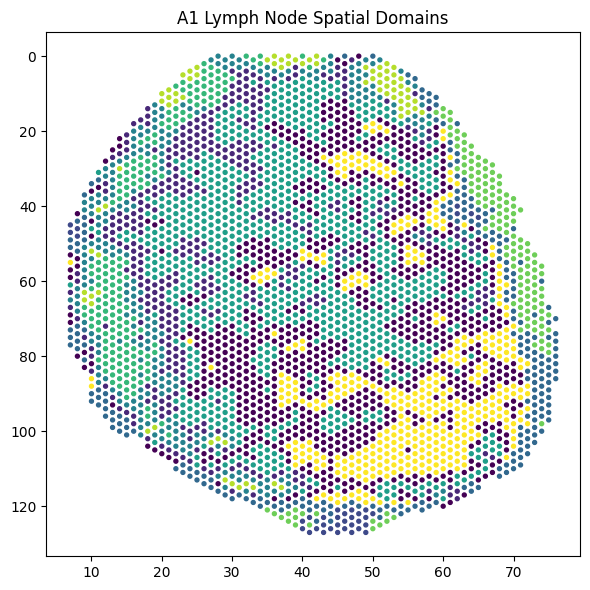

In [22]:
os.makedirs("outputs/stage1/figures", exist_ok=True)

plt.figure(figsize=(6, 6))
plt.scatter(coords[:, 0], coords[:, 1], c=labels, s=8)
plt.gca().invert_yaxis()
plt.title("A1 Lymph Node Spatial Domains")
plt.tight_layout()
plt.savefig("outputs/stage1/figures/A1_LN_spatial_clusters.png", dpi=300)
plt.show()

In [23]:
intra_alphas = [a.cpu().numpy() for a in outputs["intra_alphas"]]
inter_betas = outputs["inter_betas"].cpu().numpy()

np.save("outputs/stage1/embeddings/A1_LN_intra_alpha_mod1.npy", intra_alphas[0])
np.save("outputs/stage1/embeddings/A1_LN_intra_alpha_mod2.npy", intra_alphas[1])
np.save("outputs/stage1/embeddings/A1_LN_inter_beta.npy", inter_betas)